# Neural Operator for Mixed GMsFEM Darcy Basis Functions

This teaching notebook trains one selected multiscale basis function from a permeability field. The original experiment notebook is backed up at `backups/notebook_full_model_original.ipynb`. Start with `RUN_MODE = "quick"`, then switch to `"full"` after the notebook runs end to end.


In [1]:
from pathlib import Path

required_files = [
    Path("notebook_full_model.ipynb"),
    Path("task1.md"),
    Path("data/kappa.mat"),
    Path("data/basis.mat"),
    Path("data/kappa2.mat"),
    Path("data/basis2.mat"),
]

print("Current folder:", Path.cwd())

for f in required_files:
    print(f, "OK" if f.exists() else "MISSING")

Current folder: /root/Task1
notebook_full_model.ipynb OK
task1.md OK
data/kappa.mat OK
data/basis.mat OK
data/kappa2.mat OK
data/basis2.mat OK


## Darcy equation and mixed formulation

We consider steady flow in a heterogeneous porous medium $\Omega$. The Darcy flux $\mathbf{u}$ and pressure $p$ satisfy

$$
\mathbf{u} = -\kappa(\mathbf{x})\nabla p, \qquad \operatorname{div}\mathbf{u} = f \quad \text{in } \Omega .
$$

The equivalent pressure equation is

$$
-\operatorname{div}\left(\kappa(\mathbf{x})\nabla p\right)=f.
$$

In a mixed finite element method, flux and pressure are approximated as separate unknowns. A standard weak mixed form contains terms such as

$$
(\kappa^{-1}\mathbf{u},\mathbf{v})-(p,\operatorname{div}\mathbf{v}) \quad \text{and} \quad (\operatorname{div}\mathbf{u},q)=(f,q).
$$

This mixed viewpoint is important because it preserves local mass conservation and gives direct access to fluxes.


## GMsFEM multiscale basis functions

The Generalized Multiscale Finite Element Method builds a reduced space that still contains fine-scale information from high-contrast permeability $\kappa(\mathbf{x})$. A typical workflow is: build local snapshot spaces, solve local spectral problems, retain dominant eigenvectors, and assemble a global multiscale mixed system.

For a coarse neighborhood $\omega_i$, the snapshot space can be written as

$$
V_{\mathrm{snap}}^{(i)}=\operatorname{span}\{\psi_1^{(i)},\psi_2^{(i)},\ldots\}.
$$

The local spectral problem has the abstract form

$$
a_i(\phi,v)=\lambda s_i(\phi,v), \qquad \forall v\in V_{\mathrm{snap}}^{(i)}.
$$

The retained functions form the multiscale space $V_{\mathrm{ms}}$. In this project, each target array contains precomputed mixed GMsFEM basis functions on a $128\times128$ grid.


## Learning problem for a neural operator

For basis id $j$, the supervised task is to learn an operator

$$
\mathcal{G}_j:\kappa(\mathbf{x})\mapsto \phi_j(\mathbf{x};\kappa).
$$

The neural network $\mathcal{N}_{\theta}$ approximates $\phi_j$ from the permeability field. The training loss combines value matching and gradient matching:

$$
\mathcal{L}(\theta)=\operatorname{MSE}\left(\mathcal{N}_{\theta}(\kappa),\phi_j\right)
+\alpha\,\operatorname{MSE}\left(\nabla_h\mathcal{N}_{\theta}(\kappa),\nabla_h\phi_j\right).
$$

Python indexing is zero-based, so BASIS_INDEX = 3 means the fourth basis function.


## Network architecture

The model is an Attention U-Net with a Fourier neural-operator style preprocessing block. The Fourier block appends coordinate channels, applies learned complex weights to selected Fourier modes, and returns a spatial feature map. The U-Net encoder-decoder captures multiscale spatial features, while attention gates filter skip connections.

The input tensor has shape $(B,1,128,128)$, representing a batch of normalized log-permeability fields. The output tensor has the same spatial shape and represents one predicted basis-function field $\widehat{\phi}_j$.


## What you should save

After a successful single-basis run, save and inspect: the checkpoint in `best_model/`, training history `.mat`, metrics `.csv`, predictions `.npz`, summary `.json`, and generated `.png` figures under `outputs/teaching_single_basis/basis_XX/`. Upload small summaries and figures to GitHub, but do not upload large raw data or large checkpoints unless instructed.


## 1. Setup


In [2]:
from pathlib import Path
import json
import math
import random

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as io
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 42
DATA_DIR = Path("data")
GRID_SIZE = 128
NUM_BASIS = 12

# 'quick' mode is for quick testing and debugging, 
# while 'full' mode is for full training and evaluation.
RUN_MODE = "full"  # choices: "quick", "full"

QUICK_TRAIN_SIZE = 128
QUICK_VAL_SIZE = 32
QUICK_TEST_SIZE = 16
QUICK_EPOCHS = 2
QUICK_BATCH_SIZE = 8

FULL_TRAIN_SIZE = 3500
FULL_VAL_SIZE = 300
FULL_TEST_SIZE = 100
FULL_EPOCHS = 60
FULL_BATCH_SIZE = 32

TRAIN_SIZE = FULL_TRAIN_SIZE
TEST_SIZE = FULL_TEST_SIZE
BATCH_SIZE = FULL_BATCH_SIZE
EPOCHS = FULL_EPOCHS
GRAD_WEIGHT = 0.1
LEARNING_RATE = 1e-3
SAVE_BEST_MODEL = True

RESULTS_DIR = Path("outputs/teaching_single_basis")
OUTPUT_DIR = RESULTS_DIR
MODEL_DIR = Path("best_model")

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("run mode:", RUN_MODE)


device: cuda
run mode: full


## 2. Data Loading


In [3]:
def _read_h5_array(path, key):
    with h5py.File(path, "r") as f:
        arr = f[key][()]
    return arr


def _fix_h5_orientation(arr, leading_dim):
    if arr.shape[0] == leading_dim:
        return np.transpose(arr)
    return arr


def load_pair(data_dir, kappa_name, basis_name, grid_size=128, num_basis=12):
    kappa = _read_h5_array(data_dir / kappa_name, "Ks")
    basis = _read_h5_array(data_dir / basis_name, "bfs")

    kappa = _fix_h5_orientation(kappa, leading_dim=1)
    basis = _fix_h5_orientation(basis, leading_dim=num_basis)

    n_samples = kappa.size // (grid_size * grid_size)
    kappa = kappa.reshape(n_samples, 1, grid_size, grid_size).astype(np.float32)
    basis = basis.reshape(n_samples, grid_size * grid_size, num_basis).astype(np.float32)
    return kappa, basis


def load_all_data(data_dir=DATA_DIR, grid_size=GRID_SIZE, num_basis=NUM_BASIS):
    pairs = [
        ("kappa.mat", "basis.mat"),
        ("kappa2.mat", "basis2.mat"),
    ]
    xs, ys = zip(*(load_pair(data_dir, x_name, y_name, grid_size, num_basis) for x_name, y_name in pairs))
    x_all = np.concatenate(xs, axis=0)
    y_all = np.concatenate(ys, axis=0)
    print("x_all:", x_all.shape, "y_all:", y_all.shape)
    return x_all, y_all


In [4]:
class KappaBasisDataset(Dataset):
    def __init__(self, x, y, logk=True, normalize_x=True, x_mean=None, x_std=None):
        x = x.astype(np.float32)
        y = y.astype(np.float32)

        if logk:
            x = np.log10(np.clip(x, 1e-12, None))

        if normalize_x:
            self.x_mean = float(x.mean()) if x_mean is None else float(x_mean)
            self.x_std = float(x.std() + 1e-12) if x_std is None else float(x_std)
            x = (x - self.x_mean) / self.x_std
        else:
            self.x_mean = 0.0
            self.x_std = 1.0

        if y.ndim == 2 and y.shape[1] == GRID_SIZE * GRID_SIZE:
            y = y.reshape(-1, 1, GRID_SIZE, GRID_SIZE)
        elif y.ndim == 3 and y.shape[1:] == (GRID_SIZE, GRID_SIZE):
            y = y[:, None, :, :]
        elif y.ndim == 3 and y.shape[1:] == (GRID_SIZE * GRID_SIZE, 1):
            y = y.squeeze(-1).reshape(-1, 1, GRID_SIZE, GRID_SIZE)
        elif y.ndim == 4 and y.shape[1:] == (1, GRID_SIZE, GRID_SIZE):
            pass
        else:
            raise ValueError(f"Unexpected y shape: {y.shape}")

        self.x = torch.from_numpy(x).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


def make_loaders(
    x_all,
    y_all,
    basis_index,
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    logk=True,
):
    """Create train/val/test loaders for one basis function.

    The split is deterministic for a given seed. Training uses train_idx, epoch
    monitoring uses val_idx, and final evaluation/spectral analysis uses the
    100-sample test_idx split out from the original validation pool.
    """
    if not 0 <= basis_index < y_all.shape[-1]:
        raise ValueError(f"basis_index must be in [0, {y_all.shape[-1] - 1}], got {basis_index}")
    if train_size + test_size >= x_all.shape[0]:
        raise ValueError(
            f"train_size + test_size must be smaller than sample count; "
            f"got {train_size} + {test_size} >= {x_all.shape[0]}"
        )

    rng = np.random.default_rng(seed)
    indices = rng.permutation(x_all.shape[0])
    train_idx = indices[:train_size]
    eval_idx = indices[train_size:]
    test_idx = eval_idx[:test_size]
    val_idx = eval_idx[test_size:]

    y_basis = y_all[:, :, basis_index]
    train_dataset = KappaBasisDataset(x_all[train_idx], y_basis[train_idx], logk=logk)

    dataset_kwargs = {
        "logk": logk,
        "x_mean": train_dataset.x_mean,
        "x_std": train_dataset.x_std,
    }
    val_dataset = KappaBasisDataset(x_all[val_idx], y_basis[val_idx], **dataset_kwargs)
    test_dataset = KappaBasisDataset(x_all[test_idx], y_basis[test_idx], **dataset_kwargs)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


In [5]:
def run_sizes(run_mode=RUN_MODE):
    if run_mode == "quick":
        return QUICK_TRAIN_SIZE, QUICK_VAL_SIZE, QUICK_TEST_SIZE, QUICK_BATCH_SIZE, QUICK_EPOCHS
    if run_mode == "full":
        return FULL_TRAIN_SIZE, FULL_VAL_SIZE, FULL_TEST_SIZE, FULL_BATCH_SIZE, FULL_EPOCHS
    raise ValueError("RUN_MODE must be 'quick' or 'full'")


def make_loaders(
    x_all,
    y_all,
    basis_index,
    train_size,
    val_size,
    test_size,
    batch_size,
    seed=SEED,
    logk=True,
):
    """Create train/validation/test loaders for one selected basis function."""
    if not 0 <= basis_index < y_all.shape[-1]:
        raise ValueError(f"basis_index must be in [0, {y_all.shape[-1] - 1}], got {basis_index}")
    needed = train_size + val_size + test_size
    if needed > x_all.shape[0]:
        raise ValueError(f"Requested {needed} samples, but only {x_all.shape[0]} are available")

    rng = np.random.default_rng(seed)
    indices = rng.permutation(x_all.shape[0])
    train_idx = indices[:train_size]
    val_idx = indices[train_size:train_size + val_size]
    test_idx = indices[train_size + val_size:train_size + val_size + test_size]

    y_basis = y_all[:, :, basis_index]
    train_dataset = KappaBasisDataset(x_all[train_idx], y_basis[train_idx], logk=logk)
    dataset_kwargs = {"logk": logk, "x_mean": train_dataset.x_mean, "x_std": train_dataset.x_std}
    val_dataset = KappaBasisDataset(x_all[val_idx], y_basis[val_idx], **dataset_kwargs)
    test_dataset = KappaBasisDataset(x_all[test_idx], y_basis[test_idx], **dataset_kwargs)

    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False),
    )


## 3. Basis Reshaping and Evaluation Helpers


In [6]:
def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def as_field_batch(x):
    """Convert (H,W), (N,H,W), or (N,1,H,W) into (N,H,W)."""
    arr = _to_numpy(x).astype(np.float64, copy=False)
    if arr.ndim == 2:
        return arr[None, :, :]
    if arr.ndim == 3:
        return arr
    if arr.ndim == 4 and arr.shape[1] == 1:
        return arr[:, 0, :, :]
    if arr.ndim == 4 and arr.shape[-1] == 1:
        return arr[..., 0]
    raise ValueError(f"Unexpected field shape: {arr.shape}")


def basis_raw_to_physical_field(field, coarse_shape=(32, 32), local_shape=(4, 4)):
    """Rebuild the physical 128x128 field from coarse-cell ordered basis values."""
    arr = _to_numpy(field).astype(np.float64, copy=False)
    if arr.ndim == 2 and arr.shape == (coarse_shape[0] * local_shape[0], coarse_shape[1] * local_shape[1]):
        arr = arr.reshape(-1)
    if arr.ndim != 1:
        raise ValueError(f"Expected one flattened or 2D basis field, got {arr.shape}")
    expected = coarse_shape[0] * coarse_shape[1] * local_shape[0] * local_shape[1]
    if arr.size != expected:
        raise ValueError(f"Expected {expected} values, got {arr.size}")
    blocks = arr.reshape(coarse_shape[0], coarse_shape[1], local_shape[0], local_shape[1])
    return blocks.transpose(0, 2, 1, 3).reshape(coarse_shape[0] * local_shape[0], coarse_shape[1] * local_shape[1])


def as_physical_field_batch(x, coarse_shape=(32, 32), local_shape=(4, 4)):
    """Convert model/target basis output to physical (N,128,128) fields for spectral analysis."""
    raw = as_field_batch(x)
    return np.stack([
        basis_raw_to_physical_field(field, coarse_shape=coarse_shape, local_shape=local_shape)
        for field in raw
    ], axis=0)


def coarse_element_patch(field, coarse_elem_idx, local_shape=(4, 4), one_based=True):
    """Extract one 4x4 local basis patch from the raw coarse-cell ordered output."""
    arr = as_field_batch(field)[0].reshape(-1)
    idx = coarse_elem_idx - 1 if one_based else coarse_elem_idx
    patch_size = local_shape[0] * local_shape[1]
    start = idx * patch_size
    end = start + patch_size
    if start < 0 or end > arr.size:
        raise IndexError(f"coarse_elem_idx={coarse_elem_idx} is outside 1..{arr.size // patch_size}")
    return arr[start:end].reshape(local_shape)


def batch_r2_score(pred, target, eps=1e-12):
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)
    ss_res = ((target - pred) ** 2).sum(dim=1)
    ss_tot = ((target - target.mean(dim=1, keepdim=True)) ** 2).sum(dim=1)
    return (1.0 - ss_res / (ss_tot + eps)).mean().item()


def gradient_mse_eval(pred, target):
    dx_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    dy_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dx_true = target[:, :, 1:, :] - target[:, :, :-1, :]
    dy_true = target[:, :, :, 1:] - target[:, :, :, :-1]
    return F.mse_loss(dx_pred, dx_true) + F.mse_loss(dy_pred, dy_true)


@torch.no_grad()
def evaluate_model_on_loader(model, loader, device=device, return_predictions=True):
    """Return metrics and optionally y_true/y_pred arrays with shape (N,H,W)."""
    model.eval()
    n_samples = 0
    running_mse = 0.0
    running_r2 = 0.0
    num_batches = 0
    sum_mae = 0.0
    sum_rel_l2 = 0.0
    sum_grad_mse = 0.0
    max_abs_error = 0.0
    y_true_list, y_pred_list = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)

        if pred.shape != y.shape:
            raise ValueError(f"pred shape {pred.shape} != y shape {y.shape}")

        bsz = y.size(0)
        mse = F.mse_loss(pred, y)
        pred_flat = pred.reshape(bsz, -1)
        y_flat = y.reshape(bsz, -1)
        sample_mae = (pred_flat - y_flat).abs().mean(dim=1)
        sample_rel_l2 = torch.linalg.norm(pred_flat - y_flat, dim=1) / (torch.linalg.norm(y_flat, dim=1) + 1e-12)

        running_mse += mse.item()
        running_r2 += batch_r2_score(pred, y)
        sum_mae += sample_mae.sum().item()
        sum_rel_l2 += sample_rel_l2.sum().item()
        sum_grad_mse += gradient_mse_eval(pred, y).item() * bsz
        max_abs_error = max(max_abs_error, (pred - y).abs().max().item())
        n_samples += bsz
        num_batches += 1

        if return_predictions:
            y_true_list.append(y.detach().cpu())
            y_pred_list.append(pred.detach().cpu())

    mse_avg = running_mse / max(num_batches, 1)
    metrics = {
        "mse": mse_avg,
        "rmse": math.sqrt(mse_avg),
        "mae": sum_mae / max(n_samples, 1),
        "r2": running_r2 / max(num_batches, 1),
        "relative_l2": sum_rel_l2 / max(n_samples, 1),
        "grad_mse": sum_grad_mse / max(n_samples, 1),
        "max_abs_error": max_abs_error,
        "n_samples": n_samples,
    }

    if not return_predictions:
        return metrics

    y_true = torch.cat(y_true_list, dim=0).numpy().astype(np.float32)
    y_pred = torch.cat(y_pred_list, dim=0).numpy().astype(np.float32)
    return metrics, as_field_batch(y_true).astype(np.float32), as_field_batch(y_pred).astype(np.float32)


## 4. Model Definition


In [7]:
class FASpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2, use_softmax=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.use_softmax = use_softmax

        scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.attn1 = nn.Parameter(torch.ones(1, out_channels, modes1, modes2))
        self.attn2 = nn.Parameter(torch.ones(1, out_channels, modes1, modes2))

    @staticmethod
    def compl_mul2d(x, weights):
        return torch.einsum("bixy,ioxy->boxy", x, weights)

    def get_attention(self, attn, m1, m2):
        a = attn[:, :, :m1, :m2]
        if self.use_softmax:
            a = a.reshape(1, self.out_channels, -1)
            a = torch.softmax(a, dim=-1)
            return a.reshape(1, self.out_channels, m1, m2)
        return torch.sigmoid(a)

    def forward(self, x):
        batch_size, _, height, width = x.shape
        x_ft = torch.fft.rfft2(x, norm="ortho")
        out_ft = torch.zeros(
            batch_size,
            self.out_channels,
            height,
            width // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )

        m1 = min(self.modes1, height)
        m2 = min(self.modes2, width // 2 + 1)

        y_pos = self.compl_mul2d(x_ft[:, :, :m1, :m2], self.weights1[:, :, :m1, :m2])
        y_neg = self.compl_mul2d(x_ft[:, :, -m1:, :m2], self.weights2[:, :, :m1, :m2])
        out_ft[:, :, :m1, :m2] = y_pos * self.get_attention(self.attn1, m1, m2)
        out_ft[:, :, -m1:, :m2] = y_neg * self.get_attention(self.attn2, m1, m2)
        return torch.fft.irfft2(out_ft, s=(height, width), norm="ortho")


class FAFNO2d(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, modes1=16, modes2=16, width=32, padding=8, use_softmax=False):
        super().__init__()
        self.padding = padding
        self.fc0 = nn.Conv2d(in_channels + 2, width, kernel_size=1)

        self.convs = nn.ModuleList([
            FASpectralConv2d(width, width, modes1, modes2, use_softmax=use_softmax)
            for _ in range(4)
        ])
        self.ws = nn.ModuleList([nn.Conv2d(width, width, kernel_size=1) for _ in range(4)])
        self.fc1 = nn.Conv2d(width, 128, kernel_size=1)
        self.fc2 = nn.Conv2d(128, out_channels, kernel_size=1)

    @staticmethod
    def get_grid(shape, device):
        batch_size, _, height, width = shape
        gridx = torch.linspace(0, 1, height, device=device).view(1, 1, height, 1).repeat(batch_size, 1, 1, width)
        gridy = torch.linspace(0, 1, width, device=device).view(1, 1, 1, width).repeat(batch_size, 1, height, 1)
        return torch.cat([gridx, gridy], dim=1)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = self.fc0(torch.cat([x, grid], dim=1))

        if self.padding > 0:
            x = F.pad(x, [0, self.padding, 0, self.padding])

        for conv, w in zip(self.convs[:-1], self.ws[:-1]):
            x = F.gelu(conv(x) + w(x))
        x = self.convs[-1](x) + self.ws[-1](x)

        if self.padding > 0:
            x = x[..., :-self.padding, :-self.padding]

        x = F.gelu(self.fc1(x))
        return self.fc2(x)


In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_channels, out_channels))

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    def __init__(self, gate_channels, skip_channels, hidden_channels):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(gate_channels, hidden_channels, kernel_size=1, bias=True),
            nn.BatchNorm2d(hidden_channels),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(skip_channels, hidden_channels, kernel_size=1, bias=True),
            nn.BatchNorm2d(hidden_channels),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(hidden_channels, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )

    def forward(self, gate, skip):
        psi = F.gelu(self.W_g(gate) + self.W_x(skip))
        return skip * self.psi(psi)


class UpAtt(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            up_channels = in_channels
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            up_channels = in_channels // 2

        self.att = AttentionGate(up_channels, skip_channels, max(out_channels // 2, 1))
        self.conv = DoubleConv(up_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)
        x = F.pad(x, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        skip = self.att(x, skip)
        return self.conv(torch.cat([skip, x], dim=1))


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=32, bilinear=True, use_fno=True):
        super().__init__()
        self.pre = FAFNO2d(in_channels, in_channels, modes1=32, modes2=32, width=24, padding=4) if use_fno else nn.Identity()

        self.inc = DoubleConv(in_channels, base_channels)
        self.down1 = Down(base_channels, base_channels * 2)
        self.down2 = Down(base_channels * 2, base_channels * 4)
        self.down3 = Down(base_channels * 4, base_channels * 8)
        self.down4 = Down(base_channels * 8, base_channels * 16)

        self.up1 = UpAtt(base_channels * 16, base_channels * 8, base_channels * 8, bilinear)
        self.up2 = UpAtt(base_channels * 8, base_channels * 4, base_channels * 4, bilinear)
        self.up3 = UpAtt(base_channels * 4, base_channels * 2, base_channels * 2, bilinear)
        self.up4 = UpAtt(base_channels * 2, base_channels, base_channels, bilinear)
        self.outc = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        x = self.pre(x)
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)


## 5. Training Utilities


In [9]:
def gradient_loss(pred, target):
    dx_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    dy_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dx_true = target[:, :, 1:, :] - target[:, :, :-1, :]
    dy_true = target[:, :, :, 1:] - target[:, :, :, :-1]
    return F.mse_loss(dx_pred, dx_true) + F.mse_loss(dy_pred, dy_true)


def run_epoch(model, loader, optimizer=None, device=device, grad_weight=GRAD_WEIGHT):
    is_train = optimizer is not None
    model.train(is_train)
    running = {"loss": 0.0, "mse": 0.0, "r2": 0.0}

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for x, y in tqdm(loader, desc="Train" if is_train else "Val", leave=False):
            x = x.to(device)
            y = y.to(device)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            pred = model(x)
            if pred.shape != y.shape:
                raise ValueError(f"pred shape {pred.shape} != y shape {y.shape}")

            mse = F.mse_loss(pred, y)
            loss = mse + grad_weight * gradient_loss(pred, y)

            if is_train:
                loss.backward()
                optimizer.step()

            running["loss"] += loss.item()
            running["mse"] += mse.item()
            running["r2"] += batch_r2_score(pred.detach(), y.detach())

    num_batches = max(len(loader), 1)
    return {key: value / num_batches for key, value in running.items()}


def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    device=device,
    epochs=EPOCHS,
    grad_weight=GRAD_WEIGHT,
    save_path="best_model.pth",
    save=False,
    mat_save_path="training_history.mat",
):
    best_val_loss = float("inf")
    history = {
        "train_loss": [],
        "train_mse": [],
        "train_r2": [],
        "val_loss": [],
        "val_mse": [],
        "val_r2": [],
    }

    model.to(device)
    save_path = Path(save_path)

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer, device, grad_weight)
        val_metrics = run_epoch(model, val_loader, None, device, grad_weight)

        for metric_name in ("loss", "mse", "r2"):
            history[f"train_{metric_name}"].append(train_metrics[metric_name])
            history[f"val_{metric_name}"].append(val_metrics[metric_name])

        print(
            f"Epoch [{epoch}/{epochs}] | "
            f"Train Loss: {train_metrics['loss']:.6f}, "
            f"Train MSE: {train_metrics['mse']:.6f}, "
            f"Train R2: {train_metrics['r2']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.6f}, "
            f"Val MSE: {val_metrics['mse']:.6f}, "
            f"Val R2: {val_metrics['r2']:.4f}"
        )

        if save and val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            save_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), save_path)
            print(f"Saved best model to {save_path}")

    io.savemat(str(mat_save_path), history)
    print(f"Training history saved to {mat_save_path}")
    return history


In [10]:
def save_summary(summary_path, config, metrics):
    summary_path = Path(summary_path)
    summary_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {"config": config, "metrics": metrics}
    summary_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"Summary saved to {summary_path}")


def save_metrics_csv(metrics_path, basis_number, metrics):
    metrics_path = Path(metrics_path)
    metrics_path.parent.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame([{ "basis_id": basis_number, **metrics }])
    df.to_csv(metrics_path, index=False)
    return df


def plot_history(history, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="validation")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].set_title("Loss curve")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[1].plot(history["train_r2"], label="train")
    axes[1].plot(history["val_r2"], label="validation")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("R2")
    axes[1].set_title("R2 curve")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_input_and_basis(kappa, basis_flat, sample_idx=0, basis_index=0):
    kappa_field = kappa[sample_idx, 0]
    basis_field = basis_raw_to_physical_field(basis_flat[sample_idx, :, basis_index])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(np.log10(np.clip(kappa_field, 1e-12, None)), cmap="viridis")
    axes[0].set_title("log10 permeability")
    axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    im1 = axes[1].imshow(basis_field, cmap="coolwarm")
    axes[1].set_title(f"basis {basis_index + 1} target")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def visualize_predictions(model, loader, basis_number, output_dir, device=device, num_samples=3):
    model.eval()
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    x, y = next(iter(loader))
    x = x.to(device)
    y = y.to(device)
    pred = model(x)
    for i in range(min(num_samples, x.size(0))):
        x_i = x[i, 0].cpu().numpy()
        y_i = basis_raw_to_physical_field(y[i, 0].cpu().numpy())
        p_i = basis_raw_to_physical_field(pred[i, 0].cpu().numpy())
        e_i = np.abs(p_i - y_i)
        fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
        panels = [(x_i, "normalized input"), (y_i, "true basis"), (p_i, "predicted basis"), (e_i, "absolute error")]
        for ax, (image, title) in zip(axes, panels):
            cmap = "magma" if "error" in title else ("viridis" if "input" in title else "coolwarm")
            im = ax.imshow(image, cmap=cmap)
            ax.set_title(title)
            ax.axis("off")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        save_path = output_dir / f"basis_{basis_number:02d}_sample_{i:02d}_prediction.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved {save_path}")


## 6. Load and Inspect the Dataset


In [11]:
x_all, y_all = load_all_data()
print("Number of samples:", x_all.shape[0])
print("Number of available basis functions:", y_all.shape[-1])


x_all: (4000, 1, 128, 128) y_all: (4000, 16384, 12)
Number of samples: 4000
Number of available basis functions: 12


## 7. Choose One Basis Function

Keep this as one selected basis for the first training task.


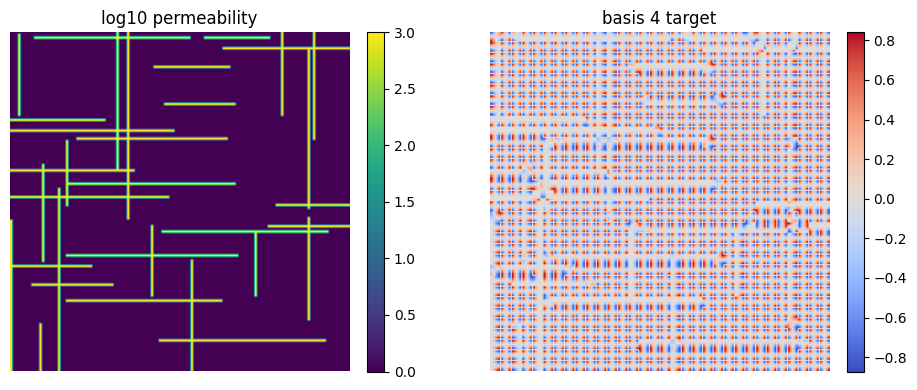

In [12]:
BASIS_INDEX = 3  # zero-based: 3 means basis function 4
BASIS_NUMBER = BASIS_INDEX + 1
plot_input_and_basis(x_all, y_all, sample_idx=0, basis_index=BASIS_INDEX)


## 8. Train One Basis Function

This is the main path for undergraduate research training. It trains only `BASIS_INDEX`.


In [13]:
train_size, val_size, test_size, batch_size, epochs = run_sizes(RUN_MODE)
BASIS_OUTPUT_DIR = RESULTS_DIR / f"basis_{BASIS_NUMBER:02d}"
BASIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

train_loader, val_loader, test_loader = make_loaders(
    x_all,
    y_all,
    basis_index=BASIS_INDEX,
    train_size=train_size,
    val_size=val_size,
    test_size=test_size,
    batch_size=batch_size,
    seed=SEED,
)

print(f"Training basis {BASIS_NUMBER} in {RUN_MODE!r} mode")
print(f"train={train_size}, val={val_size}, test={test_size}, batch={batch_size}, epochs={epochs}")
print(f"Outputs will be saved in: {BASIS_OUTPUT_DIR.resolve()}")

model = AttentionUNet(1, 1, base_channels=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    epochs=epochs,
    grad_weight=GRAD_WEIGHT,
    save_path=MODEL_DIR / f"basis_{BASIS_NUMBER:02d}_best.pt",
    save=SAVE_BEST_MODEL,
    mat_save_path=BASIS_OUTPUT_DIR / f"history_basis_{BASIS_NUMBER:02d}.mat",
)


Training basis 4 in 'full' mode
train=3500, val=300, test=100, batch=32, epochs=60
Outputs will be saved in: /root/Task1/outputs/teaching_single_basis/basis_04


Train:   0%|          | 0/110 [00:00<?, ?it/s]

Val:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch [1/60] | Train Loss: 0.121251, Train MSE: 0.096168, Train R2: 0.4570 | Val Loss: 0.085204, Val MSE: 0.064703, Val R2: 0.6351
Saved best model to best_model/basis_04_best.pt


Train:   0%|          | 0/110 [00:00<?, ?it/s]

...

Val:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch [59/60] | Train Loss: 0.005877, Train MSE: 0.004395, Train R2: 0.9752 | Val Loss: 0.017357, Val MSE: 0.012916, Val R2: 0.9272


Train:   0%|          | 0/110 [00:00<?, ?it/s]

Val:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch [60/60] | Train Loss: 0.005915, Train MSE: 0.004424, Train R2: 0.9750 | Val Loss: 0.016518, Val MSE: 0.012284, Val R2: 0.9308
Training history saved to outputs/teaching_single_basis/basis_04/history_basis_04.mat


## 9. Evaluate, Save, and Visualize


Summary saved to outputs/teaching_single_basis/basis_04/summary_basis_04.json


,basis_id,mse,rmse,mae,r2,relative_l2,grad_mse,max_abs_error,n_samples
0,4,0.012038,0.109716,0.037017,0.931886,0.260202,0.041623,1.784681,100


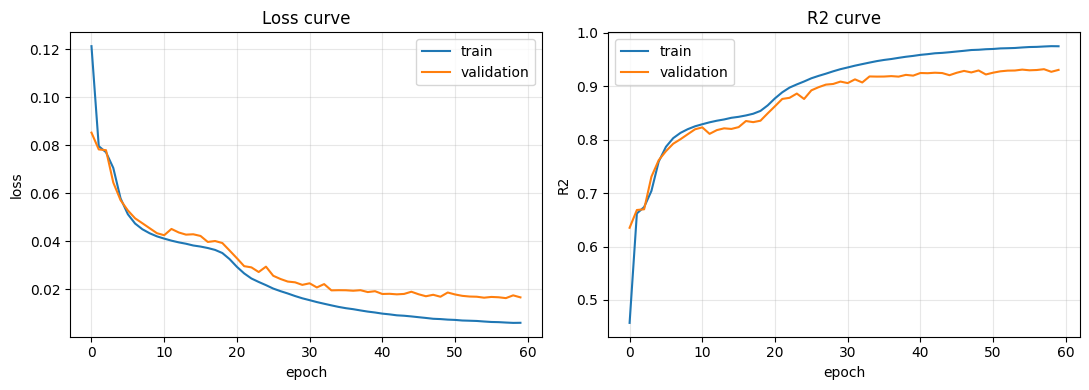

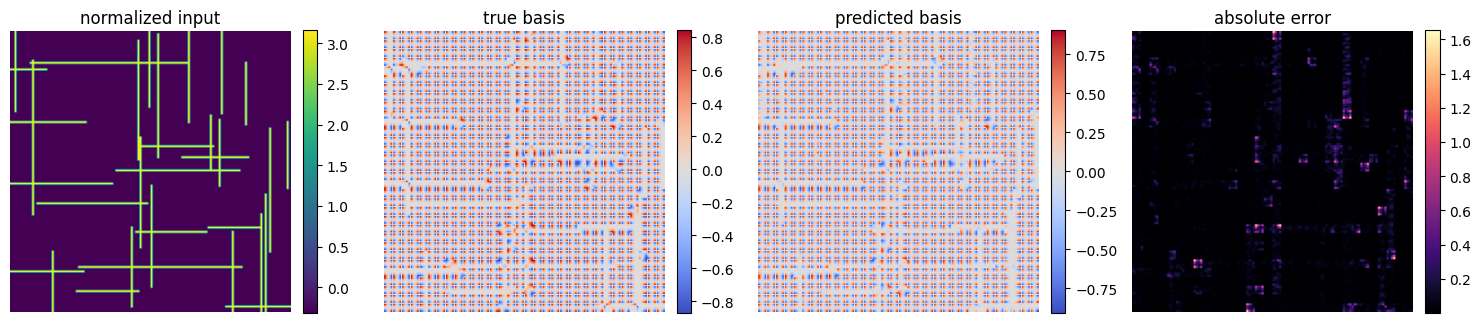

Saved outputs/teaching_single_basis/basis_04/basis_04_sample_00_prediction.png


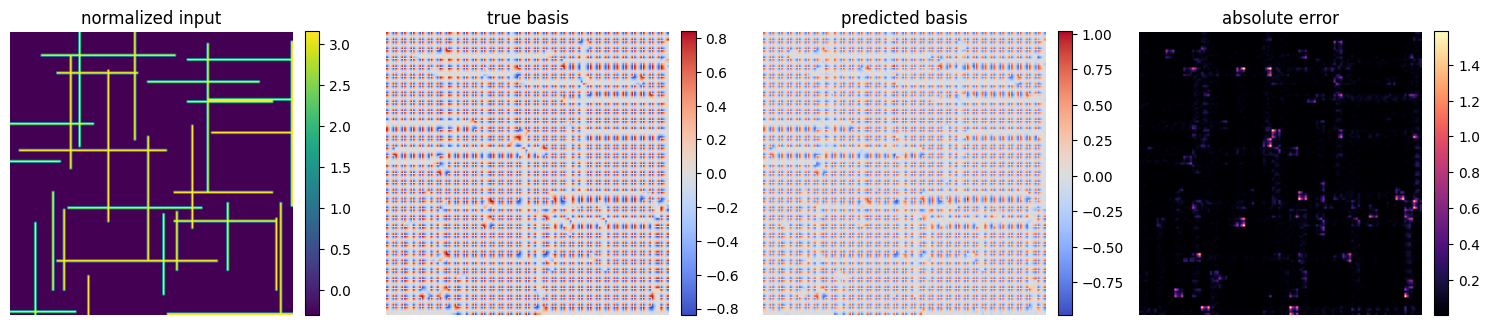

Saved outputs/teaching_single_basis/basis_04/basis_04_sample_01_prediction.png


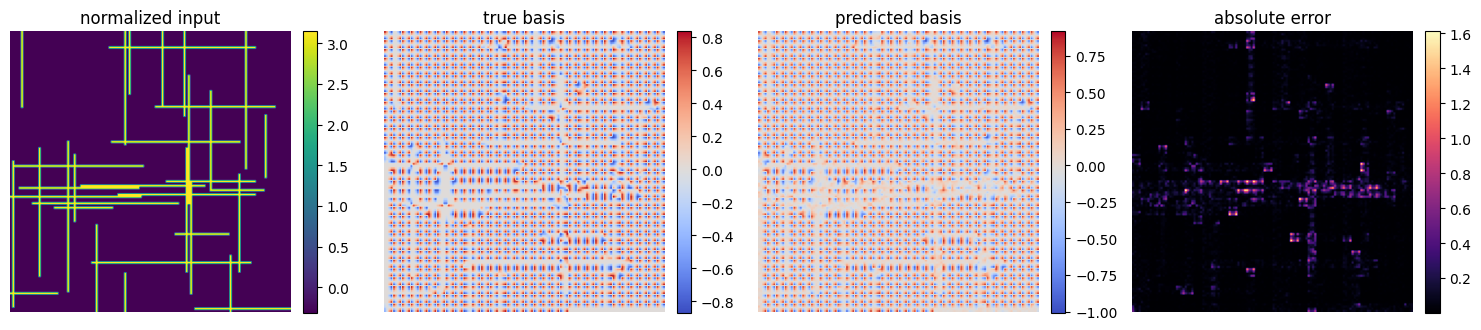

Saved outputs/teaching_single_basis/basis_04/basis_04_sample_02_prediction.png


In [14]:
metrics, y_true, y_pred = evaluate_model_on_loader(model, test_loader, device=device, return_predictions=True)
metrics_df = save_metrics_csv(BASIS_OUTPUT_DIR / f"metrics_basis_{BASIS_NUMBER:02d}.csv", BASIS_NUMBER, metrics)
np.savez_compressed(BASIS_OUTPUT_DIR / f"predictions_basis_{BASIS_NUMBER:02d}.npz", y_true=y_true, y_pred=y_pred)
config = {
    "run_mode": RUN_MODE,
    "seed": SEED,
    "basis_index_zero_based": BASIS_INDEX,
    "basis_number_one_based": BASIS_NUMBER,
    "train_size": train_size,
    "val_size": val_size,
    "test_size": test_size,
    "batch_size": batch_size,
    "epochs": epochs,
    "learning_rate": LEARNING_RATE,
    "grad_weight": GRAD_WEIGHT,
    "device": str(device),
}
save_summary(BASIS_OUTPUT_DIR / f"summary_basis_{BASIS_NUMBER:02d}.json", config, metrics)
display(metrics_df)
plot_history(history, save_path=BASIS_OUTPUT_DIR / f"history_basis_{BASIS_NUMBER:02d}.png")
visualize_predictions(model, test_loader, BASIS_NUMBER, BASIS_OUTPUT_DIR, device=device, num_samples=3)


## 10. Advanced Optional Section: Train All Basis Functions

This is not part of the first student task. It repeats the single-basis experiment for every basis function and can take much longer.


In [15]:
RUN_ADVANCED_ALL_BASES = False


def train_one_basis_experiment(basis_index, run_mode="full", seed=SEED):
    basis_number = basis_index + 1
    train_size, val_size, test_size, batch_size, epochs = run_sizes(run_mode)
    output_dir = RESULTS_DIR / "advanced_all_basis" / f"basis_{basis_number:02d}"
    output_dir.mkdir(parents=True, exist_ok=True)
    train_loader, val_loader, test_loader = make_loaders(
        x_all, y_all, basis_index, train_size, val_size, test_size, batch_size, seed=seed + basis_index
    )
    model = AttentionUNet(1, 1, base_channels=32).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    fit(model, train_loader, val_loader, optimizer, device=device, epochs=epochs, grad_weight=GRAD_WEIGHT,
        save_path=MODEL_DIR / f"basis_{basis_number:02d}_best.pt", save=SAVE_BEST_MODEL,
        mat_save_path=output_dir / f"history_basis_{basis_number:02d}.mat")
    metrics, y_true, y_pred = evaluate_model_on_loader(model, test_loader, device=device, return_predictions=True)
    save_metrics_csv(output_dir / f"metrics_basis_{basis_number:02d}.csv", basis_number, metrics)
    np.savez_compressed(output_dir / f"predictions_basis_{basis_number:02d}.npz", y_true=y_true, y_pred=y_pred)
    save_summary(output_dir / f"summary_basis_{basis_number:02d}.json",
                 {"run_mode": run_mode, "basis_index_zero_based": basis_index, "basis_number_one_based": basis_number}, metrics)
    return {"basis_id": basis_number, **metrics}


if RUN_ADVANCED_ALL_BASES:
    rows = [train_one_basis_experiment(i, run_mode="full") for i in range(NUM_BASIS)]
    all_basis_metrics = pd.DataFrame(rows)
    all_basis_dir = RESULTS_DIR / "advanced_all_basis"
    all_basis_dir.mkdir(parents=True, exist_ok=True)
    all_basis_metrics.to_csv(all_basis_dir / "metrics_all_basis.csv", index=False)
    display(all_basis_metrics)
else:
    print("Advanced all-basis training is disabled. Set RUN_ADVANCED_ALL_BASES = True to run it.")


Advanced all-basis training is disabled. Set RUN_ADVANCED_ALL_BASES = True to run it.


In [16]:
from pathlib import Path

out_dir = Path("outputs/teaching_single_basis/basis_04")
model_dir = Path("best_model")

print("Output directory exists:", out_dir.exists())
if out_dir.exists():
    print("\nFiles in output directory:")
    for p in sorted(out_dir.iterdir()):
        print(" -", p)

print("\nBest model directory exists:", model_dir.exists())
if model_dir.exists():
    print("\nFiles in best_model:")
    for p in sorted(model_dir.iterdir()):
        print(" -", p)

Output directory exists: True

Files in output directory:
 - outputs/teaching_single_basis/basis_04/basis_04_sample_00_prediction.png
 - outputs/teaching_single_basis/basis_04/basis_04_sample_01_prediction.png
 - outputs/teaching_single_basis/basis_04/basis_04_sample_02_prediction.png
 - outputs/teaching_single_basis/basis_04/history_basis_04.mat
 - outputs/teaching_single_basis/basis_04/history_basis_04.png
 - outputs/teaching_single_basis/basis_04/metrics_basis_04.csv
 - outputs/teaching_single_basis/basis_04/predictions_basis_04.npz
 - outputs/teaching_single_basis/basis_04/summary_basis_04.json

Best model directory exists: True

Files in best_model:
 - best_model/.DS_Store
 - best_model/ablation_no_attention
 - best_model/ablation_no_fno
 - best_model/ablation_no_gradient_loss
 - best_model/basis_04_best.pt


In [17]:
import json
from pathlib import Path

summary_path = Path("outputs/teaching_single_basis/basis_04/summary_basis_04.json")

with open(summary_path, "r") as f:
    summary = json.load(f)

summary

{'config': {'run_mode': 'full',
  'seed': 42,
  'basis_index_zero_based': 3,
  'basis_number_one_based': 4,
  'train_size': 3500,
  'val_size': 300,
  'test_size': 100,
  'batch_size': 32,
  'epochs': 60,
  'learning_rate': 0.001,
  'grad_weight': 0.1,
  'device': 'cuda'},
 'metrics': {'mse': 0.01203769980929792,
  'rmse': 0.10971645186250747,
  'mae': 0.03701734587550163,
  'r2': 0.9318861067295074,
  'relative_l2': 0.2602021908760071,
  'grad_mse': 0.04162321552634239,
  'max_abs_error': 1.7846806049346924,
  'n_samples': 100}}

In [18]:
import pandas as pd
from pathlib import Path

metrics_path = Path("outputs/teaching_single_basis/basis_04/metrics_basis_04.csv")

metrics = pd.read_csv(metrics_path)
metrics

,basis_id,mse,rmse,mae,r2,relative_l2,grad_mse,max_abs_error,n_samples
0,4,0.012038,0.109716,0.037017,0.931886,0.260202,0.041623,1.784681,100


Number of png files: 4
outputs/teaching_single_basis/basis_04/basis_04_sample_00_prediction.png


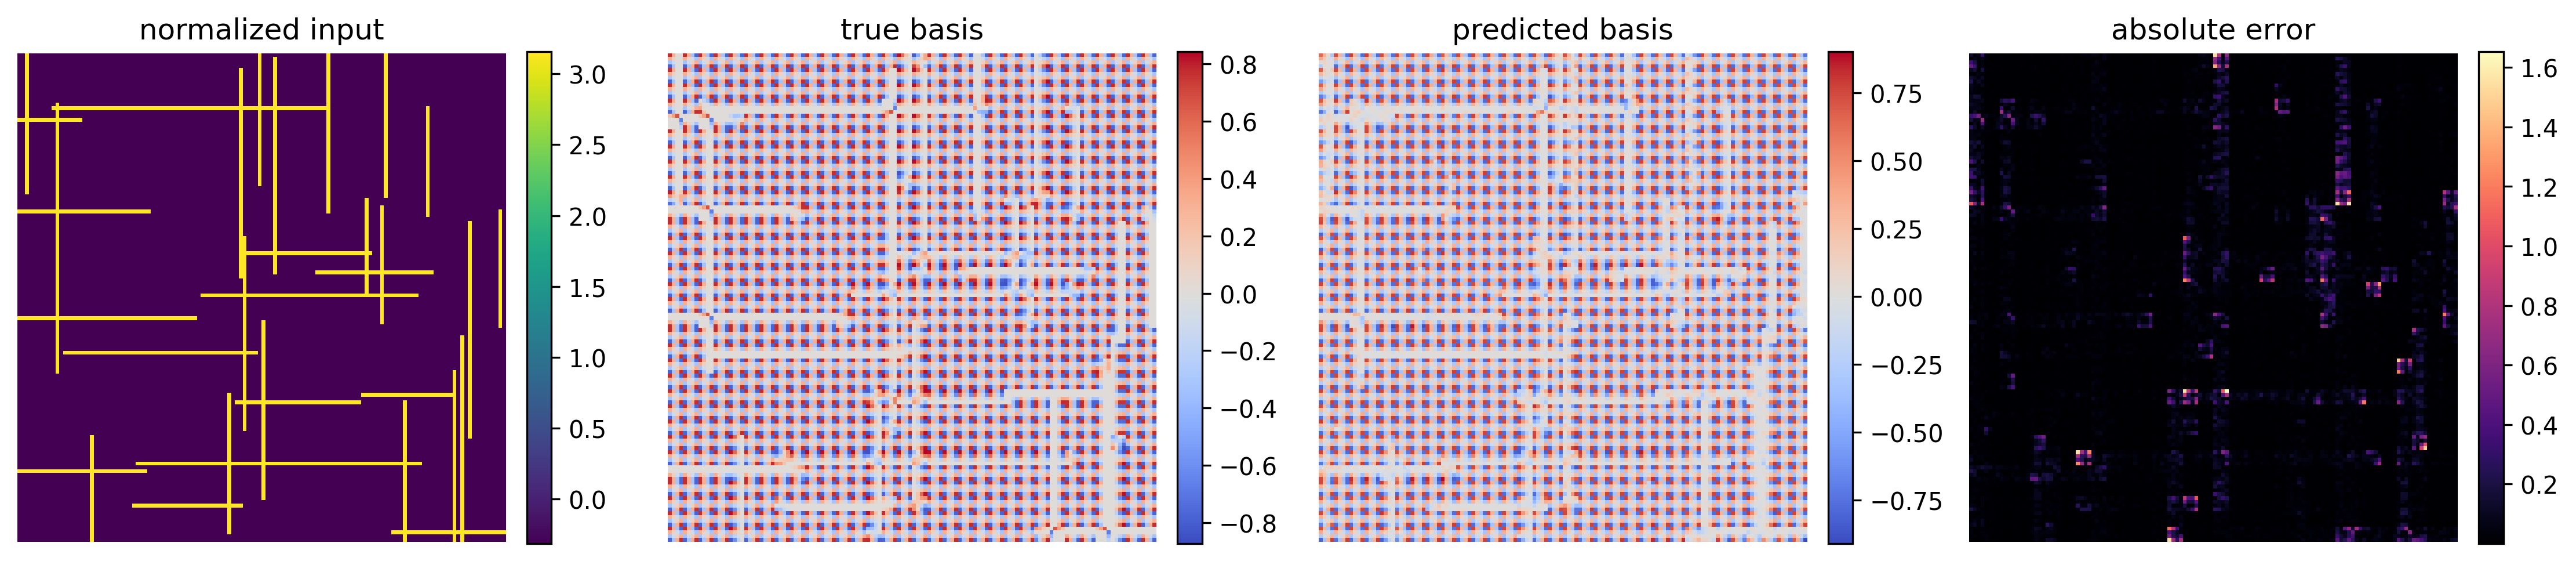

outputs/teaching_single_basis/basis_04/basis_04_sample_01_prediction.png


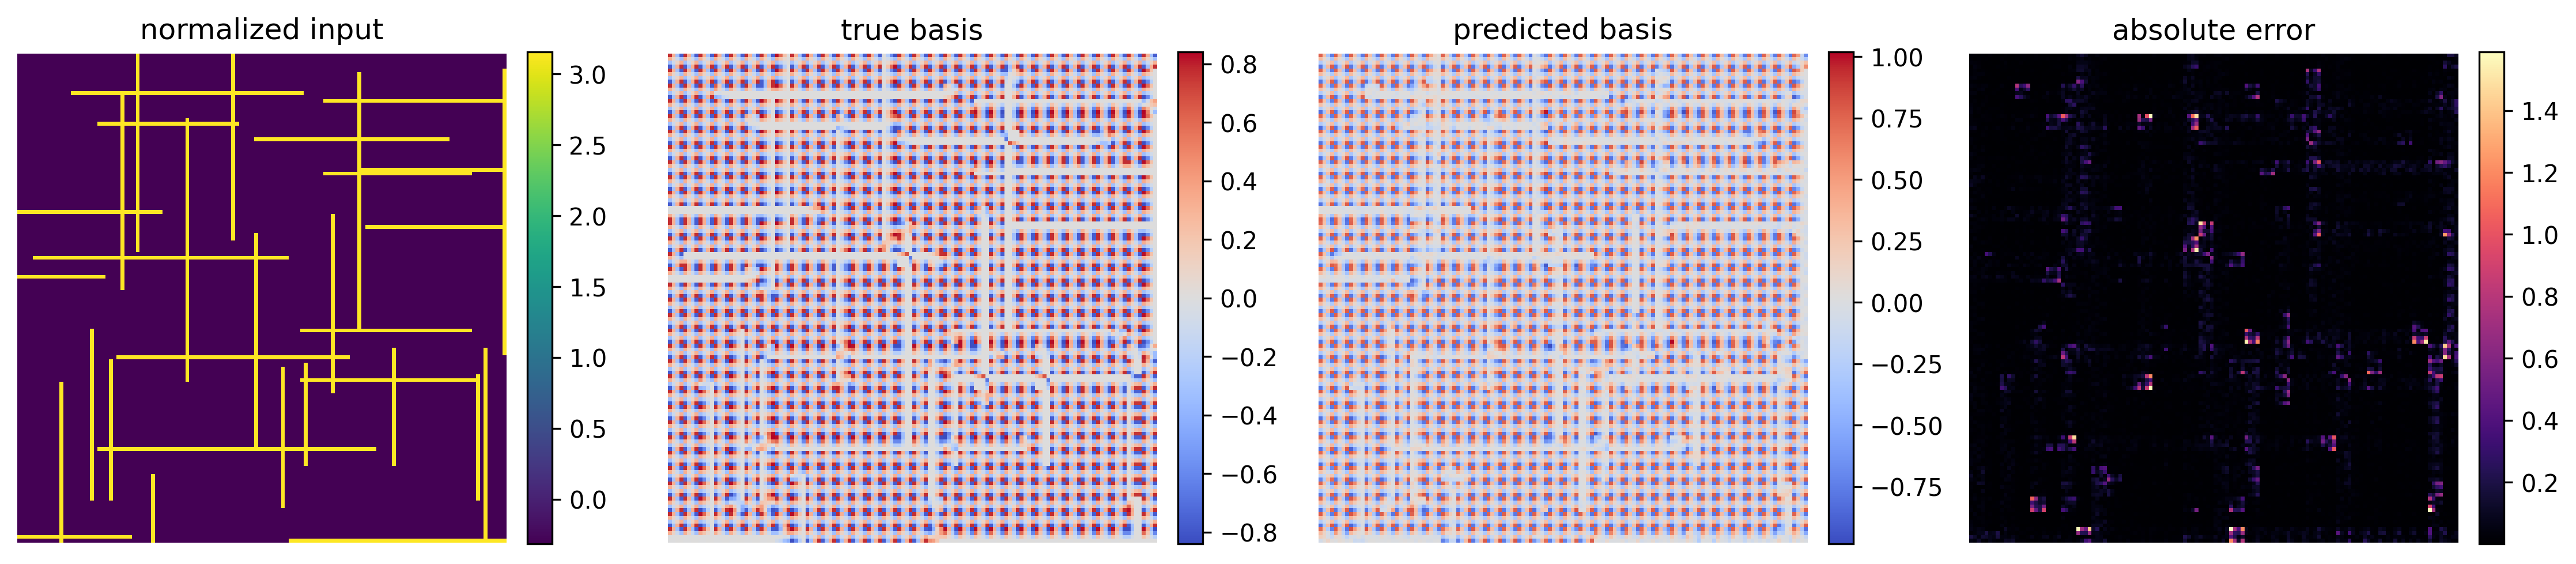

outputs/teaching_single_basis/basis_04/basis_04_sample_02_prediction.png


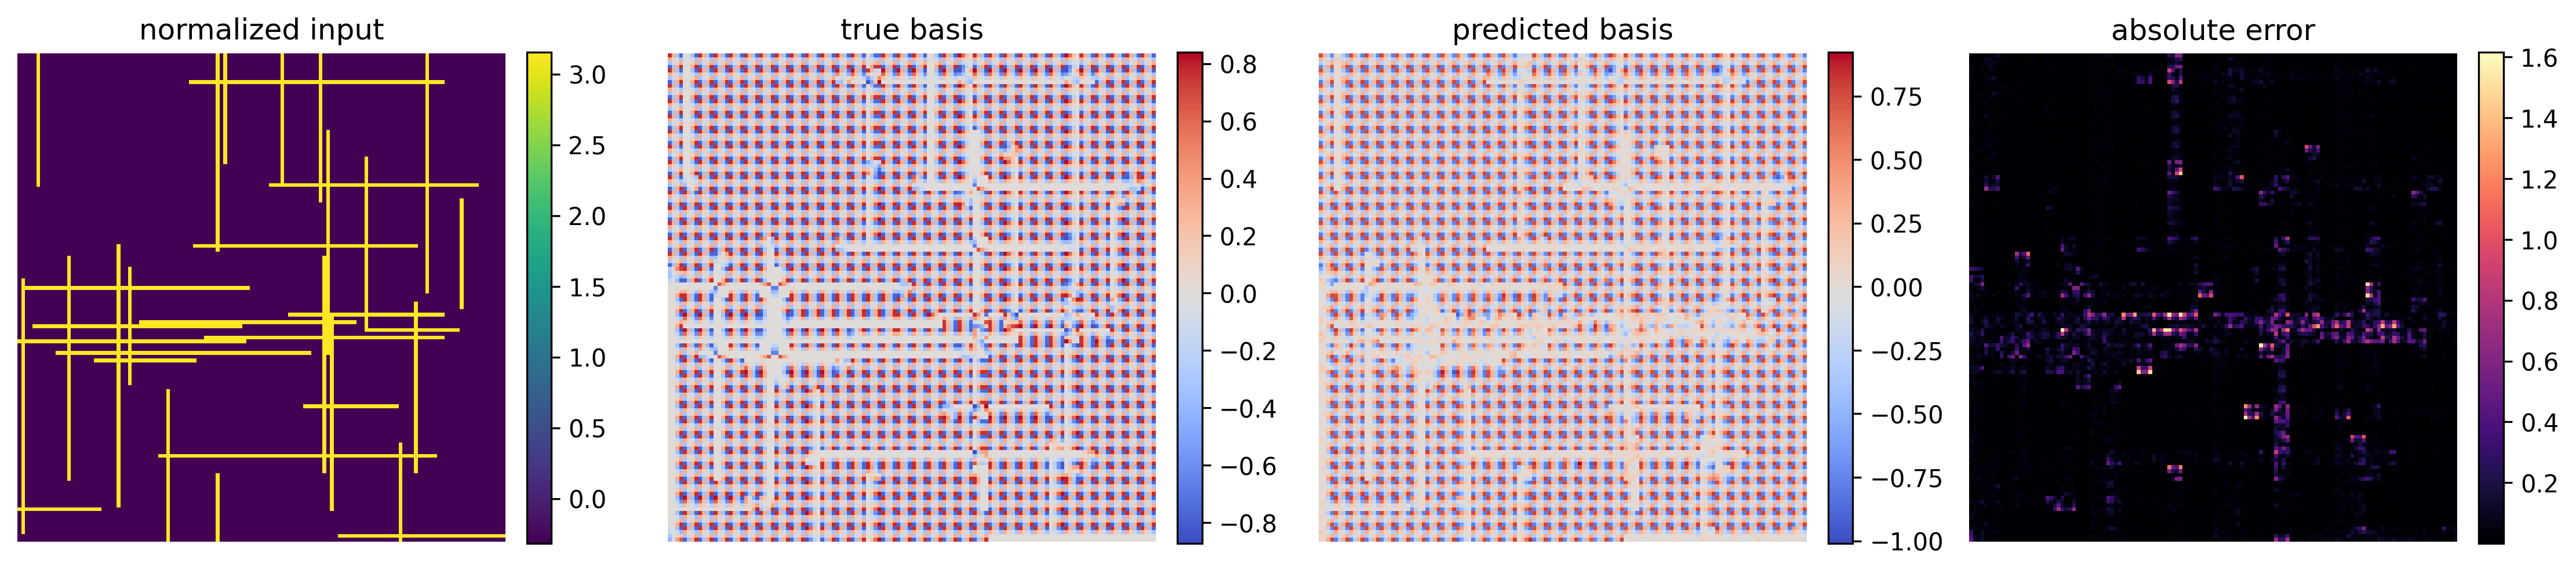

In [19]:
from pathlib import Path
from IPython.display import Image, display

out_dir = Path("outputs/teaching_single_basis/basis_04")

png_files = sorted(out_dir.glob("*.png"))
print("Number of png files:", len(png_files))

for p in png_files[:3]:
    print(p)
    display(Image(filename=str(p)))

## Full run check

- Notebook: notebook_full_model.ipynb
- RUN_MODE: full
- Basis function: basis 04
- Device: CUDA
- Result: full run completed successfully
- Output directory: outputs/teaching_single_basis/basis_04
- Checkpoint: best_model/basis_04_best.pt
- Train size: 3500
- Validation size: 300
- Test size: 100
- Epochs: 60

## Full test metrics

- MSE: 0.012038
- RMSE: 0.109716
- MAE: 0.037017
- R2: 0.931886
- Relative L2: 0.260202
- Gradient MSE: 0.041623
- Max absolute error: 1.784681
- Number of test samples: 100